# CSCI 440 - Project 4: German Credit Risk Classification with Keras MLPs

**Objectives:**
- Train deep MLPs with Keras
- Use TensorBoard for visualization
- Fine-tune neural network hyperparameters with Keras Tuner

**Dataset:** German Credit Risk (1 000 samples, 20 features, binary target: *good* / *bad*)

## 0. Install / Import Dependencies

In [ ]:
# %pip install -r requirements.txt

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 5.5/5.5 MB 49.1 MB/s  0:00:00

   ---------------- ----------------------- 2/5 [markdown]
   ---------------- ----------------------- 2/5 [markdown]
   ------------------------ --------------- 3/5 [werkzeug]
   ------------------------ --------------- 3/5 [werkzeug]
   ------------------------ --------------- 3/5 [werkzeug]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   -------------------------------- ------- 4/5 [tensorboard]
   

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import os
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')

TensorFlow : 2.21.0
Keras      : 3.14.0


---
## 1. Data Preparation

### 1.1 Load & Inspect

In [32]:
df = pd.read_csv('German-credit.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1000 non-null   str    
 1   duration                1000 non-null   float64
 2   credit_history          1000 non-null   str    
 3   purpose                 1000 non-null   str    
 4   credit_amount           1000 non-null   float64
 5   savings_status          1000 non-null   str    
 6   employment              1000 non-null   str    
 7   installment_commitment  1000 non-null   float64
 8   personal_status         1000 non-null   str    
 9   other_parties           1000 non-null   str    
 10  residence_since         1000 non-null   float64
 11  property_magnitude      1000 non-null   str    
 12  age                     1000 non-null   float64
 13  other_payment_plans     1000 non-null   str    
 14  housing                 1000 non-null   str    
 15 

In [34]:
df.describe(include='all')

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,...,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,...,4,NaN,3,3,NaN,4,NaN,2,2,2
top,no checking,NaN,existing paid,radio/tv,NaN,<100,1<=X<4,NaN,male single,none,...,car,NaN,none,own,NaN,skilled,NaN,none,yes,good
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,...,332,NaN,814,713,NaN,630,NaN,596,963,700
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,...,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN,NaN
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,...,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN,NaN
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,...,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,...,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,...,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,...,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN,NaN


Missing values per column:
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

Class distribution:
class
good    700
bad     300
Name: count, dtype: int64


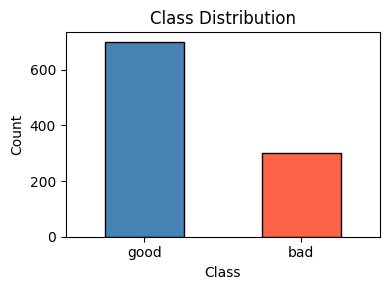

In [35]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['class'].value_counts())

fig, ax = plt.subplots(figsize=(4, 3))
df['class'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 1.2 Encode Categorical Features

In [36]:
categorical_cols = df.select_dtypes(include='object').columns.drop('class').tolist()
numerical_cols   = df.select_dtypes(include='number').columns.tolist()

print('Categorical features:', categorical_cols)
print('Numerical features  :', numerical_cols)

Categorical features: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Numerical features  : ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']


In [37]:
# One-hot encode all categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Binary-encode the target
df_encoded['target'] = (df_encoded['class'] == 'good').astype(int)
df_encoded.drop(columns=['class'], inplace=True)

print('Encoded shape:', df_encoded.shape)
df_encoded.head(3)

Encoded shape: (1000, 62)


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_0<=X<200,checking_status_<0,checking_status_>=200,...,housing_rent,job_high qualif/self emp/mgmt,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_none,own_telephone_yes,foreign_worker_no,foreign_worker_yes,target
0,6.0,1169.0,4.0,4.0,67.0,2.0,1.0,False,True,False,...,False,False,True,False,False,False,True,False,True,1
1,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,True,False,False,...,False,False,True,False,False,True,False,False,True,0
2,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,False,False,False,...,False,False,False,False,True,True,False,False,True,1


### 1.3 Feature / Target Split, Scale & Train–Test Split

In [38]:
X = df_encoded.drop(columns=['target']).values.astype(np.float32)
y = df_encoded['target'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features (fit on training set only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}  |  features: {X_train.shape[1]}')
print(f'Test samples     : {X_test.shape[0]}  |  features: {X_test.shape[1]}')
print(f'Positive rate (train): {y_train.mean():.3f}   (test): {y_test.mean():.3f}')

Training samples : 800  |  features: 61
Test samples     : 200  |  features: 61
Positive rate (train): 0.700   (test): 0.700


---
## 2. Model Building

### 2.1 Architecture Rationale (per pp. 349–353 / Table 10-2)

| Hyperparameter | Choice | Reasoning |
|---|---|---|
| Hidden layers | **2** | Good starting point; complex enough for tabular data |
| Neurons / layer | **128** | Same width in all layers ("stretch-pants"); regularised with Dropout |
| Activation | **ReLU** | Default recommended activation for hidden layers |
| Output neurons | **1** | Binary classification |
| Output activation | **Sigmoid** | Binary cross-entropy requires probability output |
| Loss | **Binary Cross-Entropy** | Standard for binary classification (Table 10-2) |
| Optimizer | **Adam** | Solid default (p. 351) |
| Learning rate | **1e-3** | Typical starting point; later tuned with Keras Tuner |
| Regularisation | **Dropout (0.3)** | Prevents overfitting instead of shrinking layer sizes |
| Stopping | **EarlyStopping** | Avoids manual epoch tuning (p. 353) |

### 2.2 Build the Baseline MLP

In [39]:
def build_baseline_model(input_dim, learning_rate=1e-3):
    """Two-hidden-layer MLP for binary classification."""
    model = keras.Sequential([
        keras.Input(shape=(input_dim,), name='input'),

        # Hidden layer 1
        layers.Dense(128, activation='relu', name='hidden_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(0.3, name='dropout_1'),

        # Hidden layer 2
        layers.Dense(128, activation='relu', name='hidden_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(0.3, name='dropout_2'),

        # Output layer
        layers.Dense(1, activation='sigmoid', name='output'),
    ], name='German_Credit_MLP')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model


baseline_model = build_baseline_model(input_dim=X_train.shape[1])
print('Model built successfully.')

Model built successfully.


### 2.3 Model Summary

In [40]:
# Standard summary: layer name, output shape, param count
baseline_model.summary()

Model: "German_Credit_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,601 (100.00 KB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [41]:
# Detailed per-layer parameter listing
print(f"{'Layer':<20} {'Output Shape':<20} {'# Params':>10}")
print('-' * 52)
total_params = 0
trainable_params = 0
non_trainable_params = 0

for layer in baseline_model.layers:
    out_shape = str(layer.output.shape)
    n_params  = layer.count_params()
    n_train   = sum(tf.size(w).numpy() for w in layer.trainable_weights)
    n_non     = sum(tf.size(w).numpy() for w in layer.non_trainable_weights)
    total_params       += n_params
    trainable_params   += n_train
    non_trainable_params += n_non
    print(f"{layer.name:<20} {out_shape:<20} {n_params:>10,}")

print('=' * 52)
print(f"{'Total params':<40} {total_params:>10,}")
print(f"{'Trainable params':<40} {trainable_params:>10,}")
print(f"{'Non-trainable params':<40} {non_trainable_params:>10,}")

Layer                Output Shape           # Params
----------------------------------------------------
hidden_1             (None, 128)               7,936
bn_1                 (None, 128)                 512
dropout_1            (None, 128)                   0
hidden_2             (None, 128)              16,512
bn_2                 (None, 128)                 512
dropout_2            (None, 128)                   0
output               (None, 1)                   129
Total params                                 25,601
Trainable params                             25,089
Non-trainable params                            512


In [42]:
# Print every weight tensor (name + shape + values) for full parameter inspection
print('\n=== All Model Weights (name | shape | values) ===\n')
for layer in baseline_model.layers:
    weights = layer.get_weights()
    if weights:
        print(f'--- Layer: {layer.name} ---')
        for w, wt in zip(layer.weights, weights):
            print(f'  {w.name}  shape={wt.shape}')
            print(f'  {wt}\n')


=== All Model Weights (name | shape | values) ===

--- Layer: hidden_1 ---
  kernel  shape=(61, 128)
  [[-0.00598863  0.07563254  0.03692122 ...  0.03250381  0.12575856
  -0.1317198 ]
 [-0.17322177  0.03357597 -0.10201108 ... -0.11839877 -0.15824068
   0.12595749]
 [ 0.13713309  0.0958547   0.03456061 ... -0.17046167  0.12255782
  -0.16289559]
 ...
 [ 0.08356687 -0.15806948 -0.08208676 ... -0.04175451 -0.00323074
   0.13836437]
 [ 0.08597797  0.08541125 -0.02867474 ... -0.0556282  -0.14807639
   0.11493164]
 [-0.07973604 -0.08617291  0.02052376 ...  0.0574578  -0.06637344
  -0.06376623]]

  bias  shape=(128,)
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.

---
## 3. Model Training

### 3.1 TensorBoard & Early Stopping Callbacks

In [43]:
# Create a timestamped log directory for TensorBoard
log_dir = os.path.join(
    'logs', 'baseline',
    datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
)
print('TensorBoard log dir:', log_dir)

callbacks = [
    keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch',
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
]

TensorBoard log dir: logs\baseline\20260406-145801


### 3.2 Train

In [44]:
EPOCHS     = 200
BATCH_SIZE = 32   # Small batch → better generalisation (LeCun recommendation)

history = baseline_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5838 - auc: 0.5925 - loss: 0.8407 - val_accuracy: 0.7083 - val_auc: 0.7184 - val_loss: 0.6021 - learning_rate: 0.0010
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6868 - auc: 0.7376 - loss: 0.6302 - val_accuracy: 0.7417 - val_auc: 0.7702 - val_loss: 0.5658 - learning_rate: 0.0010
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7176 - auc: 0.7689 - loss: 0.5530 - val_accuracy: 0.7500 - val_auc: 0.7936 - val_loss: 0.5369 - learning_rate: 0.0010
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7515 - auc: 0.8043 - loss: 0.5047 - val_accuracy: 0.7500 - val_auc: 0.8031 - val_loss: 0.5196 - learning_rate: 0.0010
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7809 - auc: 0.8270 - loss: 0.4746 - val_accuracy: 0.7750 - val_auc: 0.7991 - val_loss: 0.5118 - learning_rate: 0.0010
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7809 - auc: 0.8340 